# Case 2: Minimice CVaR

## Data load

In [1]:
import numpy as np
import pandas as pd
import cvxpy as cp
import tensorflow as tf
from sklearn.model_selection import train_test_split

import data_management as dm
from portfolios import Portfolio, Portfolio_Collection
from models import MPOModel
import risk_measures as rm
from utils import sparsemax

import warnings

warnings.filterwarnings("ignore")
tf.keras.backend.set_floatx("float32")
np.set_default_dtype = np.float32

### Index and components

In [2]:
data, data_idx = dm.DataManagement.get_data(
    asset_price_path="../data/data_comp_SP500.csv",
    idx_price_path="../data/data_idx_SP500.csv",
)

### Train/Test split

In [ ]:
# Desired dates.
ds_start_date = "2010-07-15"
ds_end_date = "2024-10-18"

# Simmulations.
n_sims = 100
simmulation_datasets = {}
rng = np.random.default_rng(seed=42)
for s in range(n_sims):
    # For each simulation, we will create a new dataset.
    # Random selection of number of assets between 10 and maximum.
    # Random selection of assets.
    # Different temporal windows.

    # Number of assets.
    min_n_assets = 10
    max_n_assets = data.shape[1]
    n_assets = rng.integers(min_n_assets, max_n_assets + 1)

    # Randomly select assets.
    selected_assets = rng.choice(data.columns, n_assets, replace=False)

    # Dataset for the simulation.
    data_sim = data[selected_assets].copy()

    # Sync dataframes
    data_sim, data_idx = dm.DataManagement.sync_dataframes(data_sim, data_idx)

    # Randomly select start and end dates for the simulation.
    start_date = rng.choice(
        pd.date_range(pd.to_datetime(ds_start_date), pd.to_datetime(ds_start_date) + pd.DateOffset(years=5), freq="D")
    )
    end_date = rng.choice(
        pd.date_range(pd.to_datetime(ds_end_date) - pd.DateOffset(years=5), pd.to_datetime(ds_end_date), freq="D")
    )

    # Split the data into training and testing sets.
    train_data, test_data, train_idx, test_idx = train_test_split(
        data_sim.loc[start_date:end_date],
        data_idx.loc[start_date:end_date],
        test_size=0.2,
        shuffle=False,
        random_state=42,
    )

    # Compute logarithmic returns.
    train_data_log_ret = dm.DataManagement.convert_prices_to_log_returns(train_data)
    train_idx_log_ret = dm.DataManagement.convert_prices_to_log_returns(train_idx)
    test_data_log_ret = dm.DataManagement.convert_prices_to_log_returns(test_data)
    test_idx_log_ret = dm.DataManagement.convert_prices_to_log_returns(test_idx)

    # Add the dataset to the dictionary.
    simmulation_datasets[s] = {
        "train_data": train_data_log_ret,
        "train_idx": train_idx_log_ret,
        "test_data": test_data_log_ret,
        "test_idx": test_idx_log_ret,
        "start_date": start_date,
        "end_date": end_date,
    }

In [4]:
train_data.shape, test_data.shape, train_idx.shape, test_idx.shape

((1688, 104), (423, 104), (1688, 1), (423, 1))

In [5]:
risk_free_return = np.float32(0.08 / 252)
# risk_free_return = 0.0

## Portfolio optimization using SKFOLIO

In [45]:
from skfolio import RiskMeasure
from skfolio.optimization import MeanRisk, ObjectiveFunction

In [46]:
skfolio_sims = {}
for s in range(n_sims):
    X_train = simmulation_datasets[s]["train_data"]
    y_train = simmulation_datasets[s]["train_idx"]

    skfolio_portfolio_name = f"Case 2 - SKFOLIO - Simulation {s}"
    skfolio_portfolio_opt = MeanRisk(
        objective_function=ObjectiveFunction.MINIMIZE_RISK,
        risk_measure=RiskMeasure.CVAR,
        min_weights=0,  # -1.0 for allowing short selling. 0.0 for no short selling.
        portfolio_params=dict(name=skfolio_portfolio_name, tag="No Tracking"),
    )
    skfolio_portfolio_opt.fit(X_train, y_train)

    skfolio_sims[s] = {
        "model": skfolio_portfolio_opt,
        "activos": X_train.columns,
        "pesos_optimos": skfolio_portfolio_opt.weights_,
        "start_date": simmulation_datasets[s]["start_date"],
        "end_date": simmulation_datasets[s]["end_date"],
    }

In [47]:
skfolio_sims[0]["model"].portfolio_params["name"]

'Case 2 - SKFOLIO - Simulation 0'

In [48]:
skfolio_portfolio = Portfolio(
    name=skfolio_sims[0]["model"].portfolio_params["name"],
    asset_weights=skfolio_sims[0]["pesos_optimos"],
    asset_names=skfolio_sims[0]["activos"],
)

Number of assets in portfolio: 13


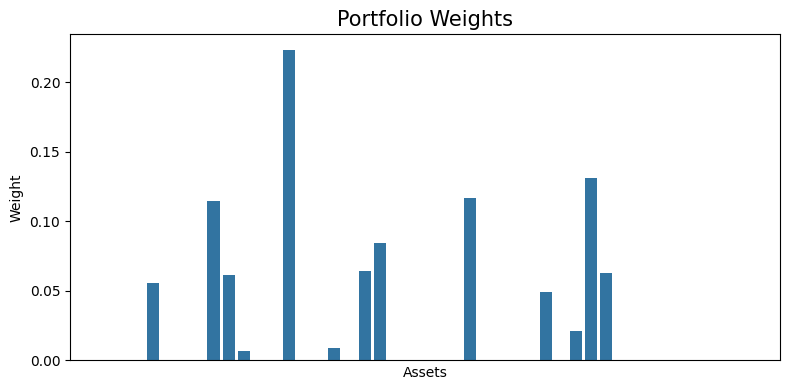

\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
 & CBRE & AON & EXC & FSLR & NSC & RMD & DHR & TDY & ODFL & CI & NEM & BIIB & MNST & GPN & PNW & TGT & HOLX & PM & MRK & HAS & PG & GS & SCHW & REGN & WYNN & TSCO & GD & TSLA & WAB & IP & WELL & COST & ORCL & FITB & KO & MKTX & KEY & APH & CE & MAS & EW & IDXX & INCY & AVGO & AMT & STT & AVY \\
\midrule
Weight & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.055328 & 0.000000 & 0.000000 & 0.000000 & 0.114853 & 0.061291 & 0.006495 & 0.000000 & 0.000000 & 0.223175 & 0.000000 & 0.000000 & 0.009209 & 0.000000 & 0.064207 & 0.084544 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.116496 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.049536 & 0.000000 & 0.021172 & 0.130896 & 0.062797 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 \\
\bottomrule
\end{tabular}



In [49]:
skfolio_portfolio.plot_weights(
    plot_ucits_limits=False,
    skip_zero_weights=False,
    zero_threshold=1e-3,
    save_as="../results/Case_02/MinCVaR_skfolio_optimizer_portfolio_weights.png",
)

Number of assets in portfolio: 13


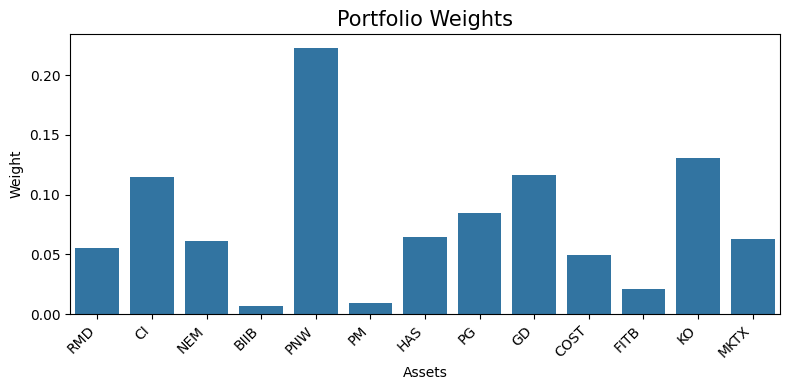

\begin{tabular}{lrrrrrrrrrrrrr}
\toprule
 & RMD & CI & NEM & BIIB & PNW & PM & HAS & PG & GD & COST & FITB & KO & MKTX \\
\midrule
Weight & 0.055328 & 0.114853 & 0.061291 & 0.006495 & 0.223175 & 0.009209 & 0.064207 & 0.084544 & 0.116496 & 0.049536 & 0.021172 & 0.130896 & 0.062797 \\
\bottomrule
\end{tabular}



In [50]:
skfolio_portfolio.plot_weights(
    plot_ucits_limits=False,
    skip_zero_weights=True,
    zero_threshold=1e-3,
    save_as="../results/Case_02/MinCVaR_skfolio_optimizer_portfolio_weights_no_zeros.png",
)

## Portfolio optimization using gradient descent

In [ ]:
def custom_loss_function():
    def loss_function(
        assets_rets,  # Assets returns
        w,  # Portfolio weights
        idx=None,  # Index returns
    ):
        # Portfolio returns.
        p_rets = tf.matmul(assets_rets, w)

        ###############
        # CVaR
        ###############
        # Calculate CVaR at 95%.
        # This function gives the result in positive.
        cvar = rm.RiskMeasures.CVaR_tf(x=p_rets, alpha=0.05)

        # Update the loss.
        loss = cvar

        return {
            "loss": loss,  # Only for training, without converting to numpy.
            "weights": w.numpy(),
            "metrics": {
                "loss": loss.numpy(),
                "cvar": cvar.numpy(),
            },
        }

    return loss_function

In [52]:
def custom_get_best_weights():
    def get_best_weights(history: list) -> np.ndarray:
        weights = pd.DataFrame([h["weights"].squeeze() for h in history])
        metrics = pd.DataFrame([h["metrics"] for h in history])
        idx_min_loss = metrics["loss"].idxmin()
        selected_weights = weights.loc[idx_min_loss].to_numpy()
        return selected_weights.squeeze()

    return get_best_weights

In [53]:
def custom_weights_function():
    return sparsemax

In [ ]:
from tqdm import tqdm

mpo_sims = {}
for s in tqdm(range(n_sims)):
    # Data.
    X_train = simmulation_datasets[s]["train_data"]
    y_train = simmulation_datasets[s]["train_idx"]

    # MPOModel parameters.
    num_assets = X_train.shape[1]
    loss_function = custom_loss_function()
    weights_function = custom_weights_function()
    get_best_weights_function = custom_get_best_weights()
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

    # Create and fit the MPOModel.
    mpo = MPOModel(
        num_assets=num_assets,
        loss_function=loss_function,
        weights_function=weights_function,
        get_best_weights_function=get_best_weights_function,
        optimizer=optimizer,
        random_weight_init=False,
    )
    history = mpo.fit(x=X_train, idx=y_train, epochs=500)

    mpo_sims[s] = {
        "model": mpo,
        "assets": X_train.columns,
        "start_date": simmulation_datasets[s]["start_date"],
        "end_date": simmulation_datasets[s]["end_date"],
    }

100%|██████████| 100/100 [27:59<00:00, 16.79s/it]


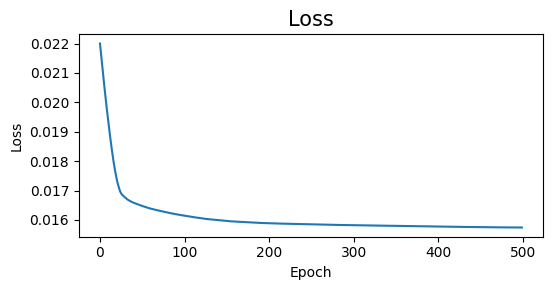

In [55]:
mpo = mpo_sims[0]["model"]
mpo.plot_all_training_metrics(
    save_as="../results/Case_02/MinCVaR_gd_optimizer_training_metrics.png",
    titles={
        "loss": "Loss",
        "cvar": "CVaR",
    },
)

In [ ]:
gd_portfolio_name = "Case 2 - GD - Simulation 0"
gd_portfolio = Portfolio(
    name=gd_portfolio_name,
    asset_weights=mpo.get_best_weights(),
    asset_names=mpo_sims[0]["assets"],
)

Number of assets in portfolio: 15


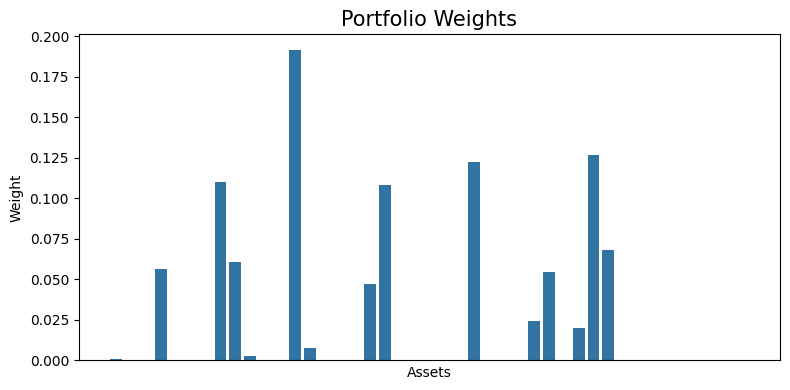

\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
 & CBRE & AON & EXC & FSLR & NSC & RMD & DHR & TDY & ODFL & CI & NEM & BIIB & MNST & GPN & PNW & TGT & HOLX & PM & MRK & HAS & PG & GS & SCHW & REGN & WYNN & TSCO & GD & TSLA & WAB & IP & WELL & COST & ORCL & FITB & KO & MKTX & KEY & APH & CE & MAS & EW & IDXX & INCY & AVGO & AMT & STT & AVY \\
\midrule
Weight & 0.000000 & 0.000000 & 0.001106 & 0.000000 & 0.000000 & 0.056100 & 0.000000 & 0.000000 & 0.000000 & 0.109747 & 0.060651 & 0.002947 & 0.000000 & 0.000000 & 0.191529 & 0.007739 & 0.000000 & 0.000000 & 0.000000 & 0.047080 & 0.107903 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.122307 & 0.000000 & 0.000000 & 0.000000 & 0.024079 & 0.054511 & 0.000000 & 0.019792 & 0.126552 & 0.067957 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 \\
\bottomrule
\end{tabular}



In [57]:
gd_portfolio.plot_weights(
    plot_ucits_limits=False,
    skip_zero_weights=False,
    save_as="../results/Case_02/MinCVaR_gd_optimizer_portfolio_weights.png",
)

Number of assets in portfolio: 15


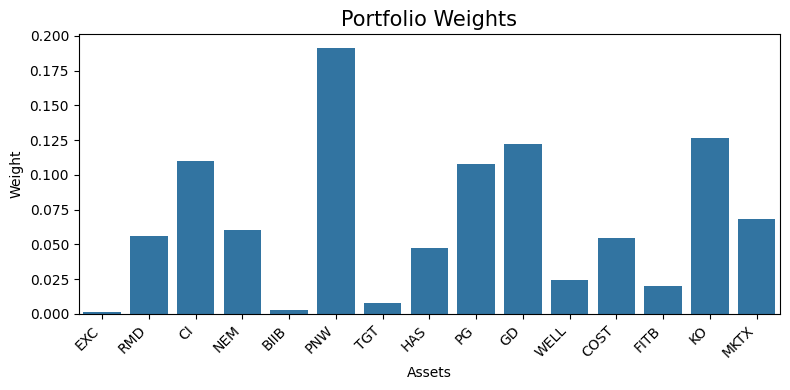

\begin{tabular}{lrrrrrrrrrrrrrrr}
\toprule
 & EXC & RMD & CI & NEM & BIIB & PNW & TGT & HAS & PG & GD & WELL & COST & FITB & KO & MKTX \\
\midrule
Weight & 0.001106 & 0.056100 & 0.109747 & 0.060651 & 0.002947 & 0.191529 & 0.007739 & 0.047080 & 0.107903 & 0.122307 & 0.024079 & 0.054511 & 0.019792 & 0.126552 & 0.067957 \\
\bottomrule
\end{tabular}



In [58]:
gd_portfolio.plot_weights(
    plot_ucits_limits=False,
    skip_zero_weights=True,
    save_as="../results/Case_02/MinCVaR_gd_optimizer_portfolio_weights_no_zeros.png",
)

## Comparison

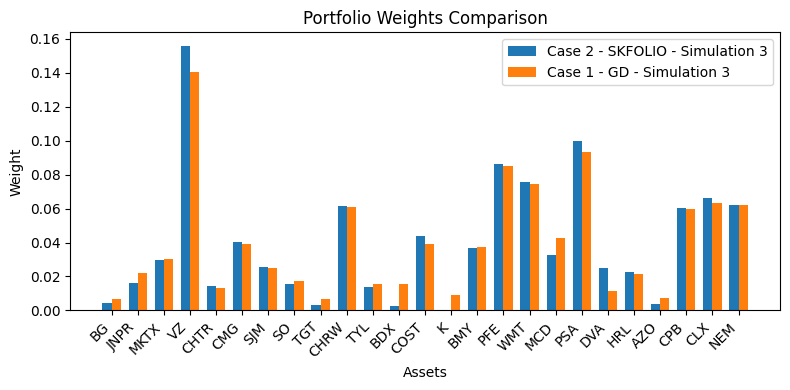

                                       BG      JNPR      MKTX        VZ  \
Case 2 - SKFOLIO - Simulation 3  0.004200  0.016334  0.029433  0.156054   
Case 1 - GD - Simulation 3       0.006663  0.022252  0.030531  0.140708   

                                     CHTR       CMG       SJM        SO  \
Case 2 - SKFOLIO - Simulation 3  0.014386  0.040556  0.025783  0.015520   
Case 1 - GD - Simulation 3       0.013298  0.039422  0.025178  0.017173   

                                      TGT      CHRW       TYL       BDX  \
Case 2 - SKFOLIO - Simulation 3  0.003464  0.061471  0.013504  0.002714   
Case 1 - GD - Simulation 3       0.006700  0.060923  0.015320  0.015473   

                                     COST         K       BMY       PFE  \
Case 2 - SKFOLIO - Simulation 3  0.043665  0.000000  0.036984  0.085995   
Case 1 - GD - Simulation 3       0.039426  0.009064  0.037332  0.085106   

                                      WMT       MCD       PSA       DVA  \
Case 2 - SKFOLIO - Si

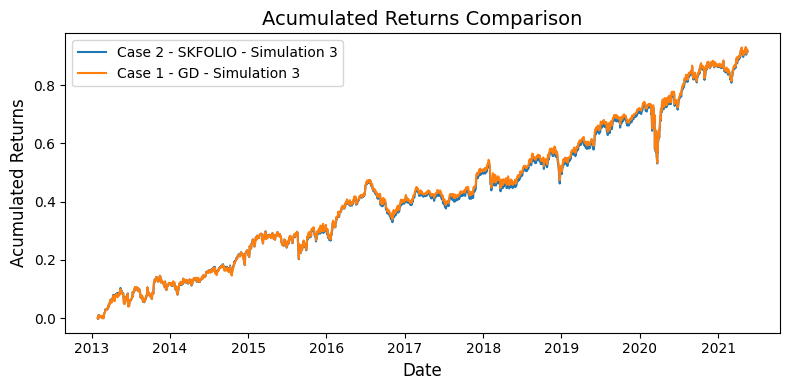

                                      Std    Sharpe  TrackingError       VaR  \
Case 2 - SKFOLIO - Simulation 3  0.007982  0.015592       0.006300  0.011092   
Case 1 - GD - Simulation 3       0.007967  0.015842       0.006212  0.011078   

                                     CVaR  WeightsOver10pct  WeightsOver5pct  
Case 2 - SKFOLIO - Simulation 3  0.017622          0.056122         0.668179  
Case 1 - GD - Simulation 3       0.017628          0.040708         0.639755  


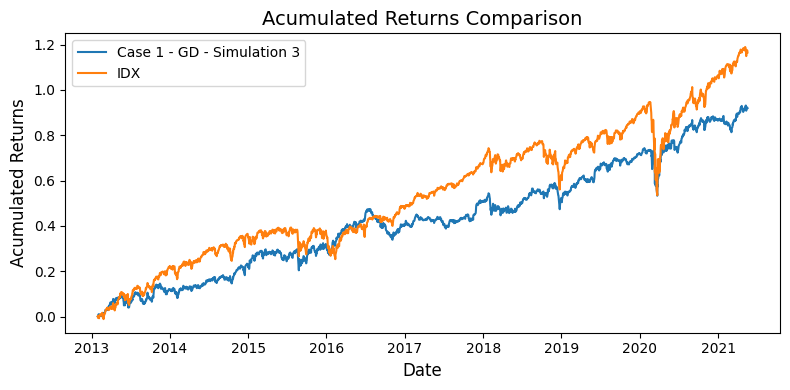

                                 Std    Sharpe  TrackingError       VaR  \
Case 1 - GD - Simulation 3  0.007967  0.015842       0.006212  0.011078   
IDX                         0.010615  0.022772       0.000000  0.015320   

                                CVaR  WeightsOver10pct  WeightsOver5pct  
Case 1 - GD - Simulation 3  0.017628          0.040708         0.639755  
IDX                         0.026672               NaN              NaN  
************************
Start date: 2013-01-26T00:00:00.000000000
End date: 2023-06-17T00:00:00.000000000


In [ ]:
n_sim = 3

# Allows us to store and compare the different portfolios.
portfolios = Portfolio_Collection(portfolio_names=[], portfolio_weights=[], asset_names=mpo_sims[n_sim]["assets"])

# SKFOLIO portfolio.
skfolio_portfolio = Portfolio(
    name=skfolio_sims[n_sim]["model"].portfolio_params["name"],
    asset_weights=skfolio_sims[n_sim]["optimal_weights"],
    asset_names=skfolio_sims[n_sim]["assets"],
)
portfolios.replace_or_add_portfolio(
    name=skfolio_portfolio.name,
    new_portfolio=skfolio_portfolio,
)

# GD Portfolio.
mpo = mpo_sims[n_sim]["model"]
gd_portfolio_name = f"Case 1 - GD - Simulation {n_sim}"
gd_portfolio = Portfolio(
    name=gd_portfolio_name,
    asset_weights=mpo.get_best_weights(),
    asset_names=mpo_sims[n_sim]["assets"],
)
portfolios.replace_or_add_portfolio(name=gd_portfolio.name, new_portfolio=gd_portfolio)

# Plotting the comparison of the two portfolios.
portfolios.plot_weight_comparison(
    portfolio_names=[
        skfolio_portfolio.name,
        gd_portfolio.name,
    ],
    plot_ucits_limits=False,
    skip_zero_weights=True,
    zero_threshold=1e-3,
    save_as="../results/Case_02/MinCVaR_portfolio_weights_comparison.png",
)

portfolios.plot_cumulative_returns(
    asset_returns=simmulation_datasets[n_sim]["train_data"],
    idx_returns=simmulation_datasets[n_sim]["train_idx"],
    portfolio_names=[
        skfolio_portfolio.name,
        gd_portfolio.name,
    ],
    plot_idx=False,
    comparable_returns=[],
    rf=risk_free_return,
    zero_start=True,
    save_as="../results/Case_02/MinCVaR_portfolio_cumulative_returns_comparison.png",
)

portfolios.plot_cumulative_returns(
    asset_returns=simmulation_datasets[n_sim]["train_data"],
    idx_returns=simmulation_datasets[n_sim]["train_idx"],
    portfolio_names=[
        gd_portfolio.name,
    ],
    plot_idx=True,
    comparable_returns=[],
    rf=risk_free_return,
    zero_start=True,
    save_as="../results/Case_02/MinCVaR_portfolio_cumulative_returns_idx_comparison.png",
)

print("************************")
print(f"Start date: {simmulation_datasets[n_sim]['start_date']}")
print(f"End date: {simmulation_datasets[n_sim]['end_date']}")

MSE de vectores de pesos

In [ ]:
errors = []
for k in skfolio_sims.keys():
    u = skfolio_sims[k]["optimal_weights"]
    v = mpo_sims[k]["model"].get_best_weights()
    squared_error = np.sum((u - v) ** 2)
    errors.append(squared_error)
mse = np.mean(errors)
print(f"Mean Squared Error between SKFOLIO and GD portfolios: {mse}")

Mean Squared Error between SKFOLIO and GD portfolios: 0.003645937422647437


MSE of CVaR

In [ ]:
from risk_measures import RiskMeasures

errors = []
for k in skfolio_sims.keys():
    u = skfolio_sims[k]["optimal_weights"]
    v = mpo_sims[k]["model"].get_best_weights()

    # Compute metrics.
    skfolio_cvar = RiskMeasures.CVaR_Hist(X=simmulation_datasets[k]["train_data"].dot(u), alpha=0.05)
    gd_cvar = RiskMeasures.CVaR_Hist(X=simmulation_datasets[k]["train_data"].dot(v), alpha=0.05)
    squared_error = (skfolio_cvar - gd_cvar) ** 2

    errors.append(squared_error)
mse = np.mean(errors)
print(f"Mean Squared Error between SKFOLIO and GD CVaR: {mse}")

Mean Squared Error between SKFOLIO and GD CVaR: 8.77754359621466e-10
